In [1]:
import numpy as np
import pandas as pd
import os
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution
from scipy.optimize import minimize

In [2]:
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"
os.listdir(INPUT)[1]

df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[1]), sep=";")
df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])

In [17]:
y = df['PRECIPITACAO TOTAL, DIARIO(mm)'].values
y

array([56.6, 37.4,  1.2, ...,  0. ,  0. ,  0. ], shape=(3650,))

## Methods for interpolating

In [78]:
y = df['precipitation original'].astype(float).interpolate(method = 'linear').values

In [131]:
df['doy'] = pd.to_datetime(df['Data Medicao'], format="%d/%m/%Y").dt.dayofyear
clim = df.groupby('doy')['precipitation original'].mean()
y = df['precipitation original'].fillna(df['doy'].map(clim)).values

## Modelling

In [18]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    c_phi,
    kappa_gamma_phi,

    # π dynamics: persistent ARX
    omega0,
    rho,
    omega_y,   # array of ω_k for y lags

    # GB2 shape
    gamma,
    xi,
    zeta,

    harmonics,
    period,
    y,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t for scale
    - Persistent ARX logit for π_t:
        η_t = ω0 + ρ η_{t-1} + Σ ω_k y[t-k]
    - Trigonometric GAS seasonality on φ only

    Model defined only for t >= K
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    # ---------- Validity ----------
    if gamma <= 0 or xi <= 0 or zeta <= gamma:
        return 1e12
    if not (0 < alpha_phi < 1):
        return 1e12
    if not (-0.99 < rho < 0.99):
        return 1e12

    # ---------- Effective sample ----------
    n_eff = T - K

    mu_phi = np.zeros(n_eff + 1)
    phi = np.zeros(n_eff)
    eta = np.zeros(n_eff)
    pi = np.zeros(n_eff)
    score_phi = np.zeros(n_eff)

    mu_phi[0] = mu0_phi

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # φ dynamics
        phi[i] = mu_phi[i] + np.sum(gamma_phi)

        # π dynamics (persistent ARX)
        y_lags = y[t-K:t][::-1]  # [y[t-1], ..., y[t-K]]
        eta[i] = omega0 + rho * (eta[i-1] if i > 0 else 0.0) + np.dot(omega_y, y_lags)
        pi[i] = expit(eta[i])

        if not np.isfinite(phi[i]) or not np.isfinite(pi[i]):
            return 1e12

        # ---------- Likelihood ----------
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[i] + 1e-12)
            else:
                ll = np.log(pi[i] + 1e-12) + gb2.logpdf(
                    y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
                )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # ---------- φ-score ----------
        if y[t] > 0:
            score_phi[i] = gb2.score(
                y[t], phi=phi[i], gamma=gamma, xi=xi, zeta=zeta
            )[0]
        else:
            score_phi[i] = 0.0

        # ---------- GAS update for φ ----------
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ---------- Trigonometric seasonality on φ ----------
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = (
                np.cos(lam) * g
                + np.sin(lam) * gs
                + kappa_gamma_phi * score_phi[i]
            )
            gamma_star_phi[j] = (
                np.cos(lam) * gs
                - np.sin(lam) * g
                + kappa_gamma_phi * score_phi[i]
            )

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "pi": pi,
            "eta": eta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [19]:
K = 3
harmonics = 10
period = 365.25

theta0 = np.concatenate([
    np.array([
        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
        0.5,        # c_phi
        0.95,       # alpha_phi
        0.01,       # kappa_phi
        0.01,       # kappa_gamma_phi

        -1.0,       # omega0
        0.5,        # rho

        0.01, 0.01, 0.01,   # omega_y (K=3)

        1.2,        # gamma
        1.2,        # xi
        3.0         # zeta
    ]),
    np.zeros(harmonics),        # gamma0_phi
    np.zeros(harmonics)         # gamma_star0_phi
])


In [20]:
bounds = [
    (-2.0, 4.0),     # mu0_phi
    (0.0, 5.0),      # c_phi
    (0.00, 0.995),   # alpha_phi
    (1e-4, 0.1),     # kappa_phi
    (1e-4, 0.1),     # kappa_gamma_phi

    (-10.0, 2.0),    # omega0
    (0.00, 0.99),   # rho

] + [(-5.0, 5.0)] * K + [   # omega_y

    (0.5, 2.5),      # gamma
    (0.5, 3.0),      # xi
    (2.5, 6.0)       # zeta

] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics


In [21]:
def objective_zagb2(theta, y, K, harmonics=10, period=365):

    idx = 0

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma=gamma,
        xi=xi,
        zeta=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        mode="loglik"
    )


In [22]:
def AIC_zagb2(theta, y, K, harmonics=10, period=365):

    idx = 0

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    loglik = -iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma=gamma,
        xi=xi,
        zeta=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        mode="loglik"
    )
    
    return 2 * (len(theta) - loglik)


In [23]:
from scipy.optimize import minimize

res = minimize(
    objective_zagb2,
    theta0,
    args=(y, K, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-3,
        "ftol": 1e-3
    }
)


C:\Users\ilang\AppData\Local\Temp\ipykernel_31616\3196001706.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


In [24]:
out = iterate_zagb2(
    mu0_phi=res.x[0],
    gamma0_phi=res.x[-2*harmonics:-harmonics],
    gamma_star0_phi=res.x[-harmonics:],
    alpha_phi=res.x[2],
    kappa_phi=res.x[3],
    c_phi=res.x[1],
    kappa_gamma_phi=res.x[4],

    omega0=res.x[5],
    rho=res.x[6],
    omega_y=res.x[7:7+K],

    gamma=res.x[7+K],
    xi=res.x[8+K],
    zeta=res.x[9+K],

    harmonics=harmonics,
    period=period,
    y=y,
    mode="filter"
)

phi_hat = out["phi"]
pi_hat  = out["pi"]
eta_hat = out["eta"]


In [25]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """

    y = np.asarray(y)

    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    # avoid division by zero / invalid
    y_pos = np.maximum(y, 1e-12)

    z = (y_pos / sigma) ** p
    u = z / (1.0 + z)

    # numerical safety
    u = np.clip(u, 1e-12, 1.0 - 1e-12)

    return betainc(a, b, u)


In [26]:
from numpy.random import default_rng
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution

rng = default_rng(123)

K = len(res.x[7:7+K])  # same K used in estimation
y_eff = y[K:]         # effective sample aligned with φ,π

pit = np.zeros(len(y_eff))

for i in range(len(y_eff)):
    pi_t = pi_hat[i]

    if y_eff[i] == 0:
        pit[i] = rng.uniform(0.0, 1.0 - pi_t)
    else:
        F_gb2 = gb2_cdf(
            y_eff[i],
            phi=phi_hat[i],
            gamma=res.x[7+K],
            xi=res.x[8+K],
            zeta=res.x[9+K]
        )
        pit[i] = (1 - pi_t) + pi_t * F_gb2


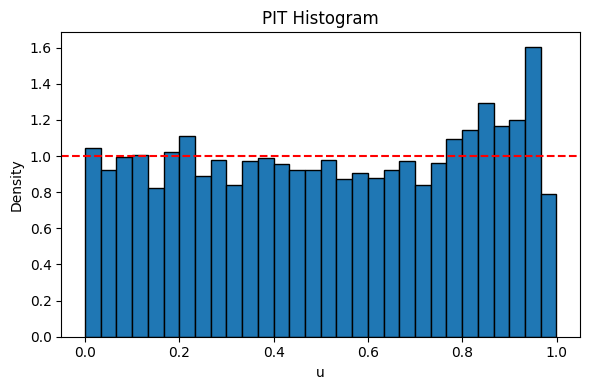

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


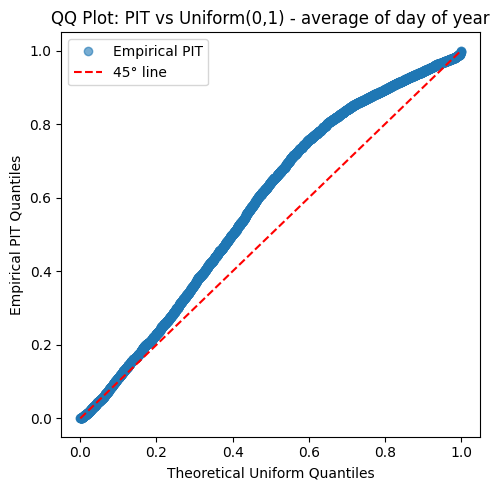

In [37]:
import numpy as np

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1) - average of day of year")
plt.legend()
plt.tight_layout()
plt.show()


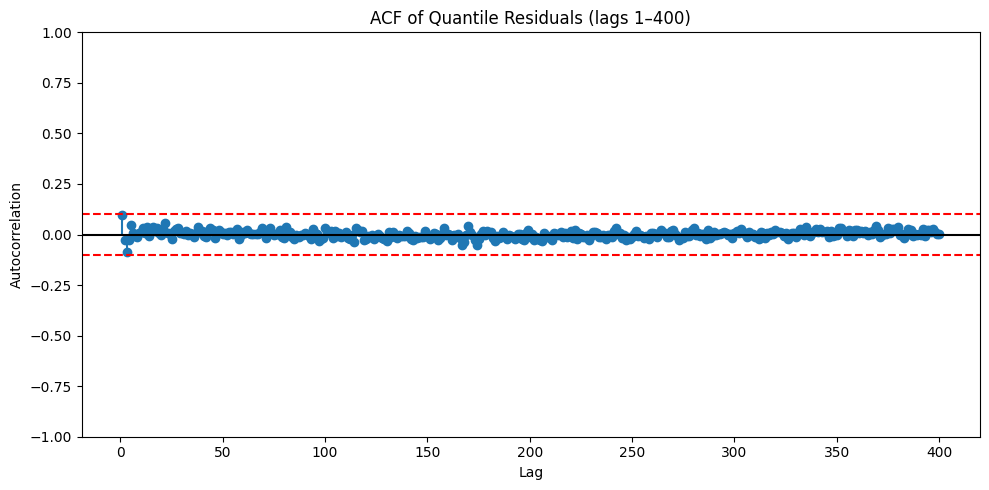

In [38]:
from scipy.stats import norm

qr = norm.ppf(pit)
qr = qr[np.isfinite(qr)]  # safety


from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()


## Harmonics AIC

In [6]:
df.columns

Index(['Data Medicao', 'PRECIPITACAO TOTAL, DIARIO(mm)', 'Ano'], dtype='object')

In [9]:
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"
locs = []
for i,file in enumerate(os.listdir(INPUT)):
    if file.split("_")[-1] == "train.csv":
        df = pd.read_csv(os.path.join(INPUT, file), sep=";")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])        
        loc = file.split(".")[0]
        locs.append(loc)

In [18]:
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"

aic_list = []

for i,file in enumerate(os.listdir(INPUT)):
    
    if file.split("_")[-1] == "train.csv":
        df = pd.read_csv(os.path.join(INPUT, file), sep=";")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])
        
        y = df['PRECIPITACAO TOTAL, DIARIO(mm)'].values
        
        loc = file.split(".")[0].split("_")[0]
        
        K = 3
        
        aic = []
        
        i = 0
        for h in range(5, 180, 5):
            harmonics = h
            period = 365.25
            
            bounds = [
                (-2.0, 4.0),     # mu0_phi
                (0.0, 5.0),      # c_phi
                (0.00, 0.995),   # alpha_phi
                (1e-4, 0.1),     # kappa_phi
                (1e-4, 0.1),     # kappa_gamma_phi

                (-10.0, 2.0),    # omega0
                (0.00, 0.99),   # rho

            ] + [(-5.0, 5.0)] * K + [   # omega_y

                (0.5, 2.5),      # gamma
                (0.5, 3.0),      # xi
                (2.5, 6.0)       # zeta

            ] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics


            theta0 = np.concatenate([
                np.array([
                    np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                    0.5,        # c_phi
                    0.95,       # alpha_phi
                    0.01,       # kappa_phi
                    0.01,       # kappa_gamma_phi

                    -1.0,       # omega0
                    0.5,        # rho

                    0.01, 0.01, 0.01,   # omega_y (K=3)

                    1.2,        # gamma
                    1.2,        # xi
                    3.0         # zeta
                ]),
                np.zeros(harmonics),        # gamma0_phi
                np.zeros(harmonics)         # gamma_star0_phi
            ])
            
            res = minimize(
                objective_zagb2,
                theta0,
                args=(y, K, harmonics, period),
                method="L-BFGS-B",
                bounds=bounds,
                options={
                    "disp": True,
                    "maxiter": 500,
                    "gtol": 1e-3,
                    "ftol": 1e-3
                }
            )
            
            aic.append(AIC_zagb2(res.x, y, K, harmonics=h, period=365.25))
            
            if i > 0:
                if aic[i] > aic[i-1]:
                    break
                
            i += 1
        
        aic_list.append(aic)


C:\Users\ilang\AppData\Local\Temp\ipykernel_45100\441774650.py:65: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\ilang\AppData\Local\Temp\ipykernel_45100\441774650.py:65: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\ilang\AppData\Local\Temp\ipykernel_45100\441774650.py:65: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\ilang\AppData\Local\Temp\ipykernel_45100\441774650.py:65: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\ilang\AppData\Local\Temp\ipykernel_45100\441774650.py:65: DeprecationWarning: s

In [19]:
aic_list

[[np.float64(11283.16465618972), np.float64(11306.438363132216)],
 [np.float64(18774.0754813878), np.float64(18813.917735077346)],
 [np.float64(13080.373475338214), np.float64(13353.077245951274)],
 [np.float64(16311.654170056518), np.float64(16650.18423943506)],
 [np.float64(19719.505724449697), np.float64(19752.973003825744)],
 [np.float64(12608.800919530775), np.float64(12630.823695873043)],
 [np.float64(16481.435060533437),
  np.float64(16481.379648383976),
  np.float64(16961.038894487207)],
 [np.float64(13314.55155436477),
  np.float64(13257.752870076964),
  np.float64(13294.234614670617)]]

In [26]:
aic_list[0]

[np.float64(11283.16465618972), np.float64(11306.438363132216)]

Text(0.5, 0, 'Harmonics')

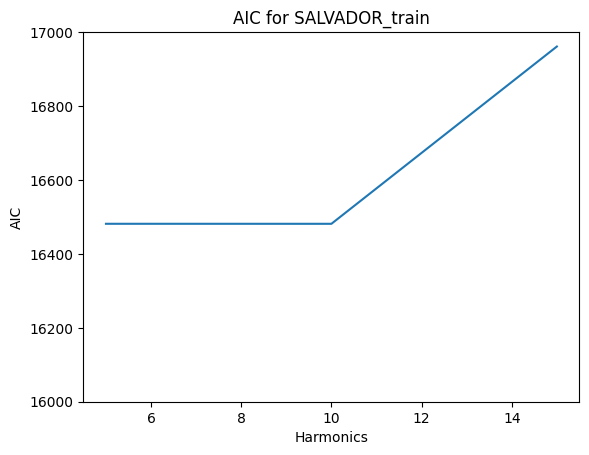

In [32]:
import matplotlib.pyplot as plt
j = 6
plt.plot([5*(1+i)for i,_ in enumerate(aic_list[j])],aic_list[j])
plt.ylim((16000, 17000))
plt.title(f"AIC for {locs[j]}")
plt.ylabel("AIC")
plt.xlabel("Harmonics")

In [21]:
df_latex = pd.DataFrame(
    data={
        "Location": locs,
        "Harmonics for best AIC": [5*(len(x)-1) for x in aic_list]
    }
)

print(df_latex.to_latex(index=False))

\begin{tabular}{lr}
\toprule
Location & Harmonics for best AIC \\
\midrule
BELO HORIZONTE_train & 5 \\
CRUZEIRO DO SUL (ACRE)_train & 5 \\
GARANHUNS (PERNAMBUCO)_train & 5 \\
MACEIÓ_train & 5 \\
MANAUS_train & 5 \\
RIO DE JANEIRO (INMET)_train & 5 \\
SALVADOR_train & 10 \\
SÃO PAULO_train & 10 \\
\bottomrule
\end{tabular}

